# Tutorial 6.2: Application of PRISM to P22 Mouse Brain Adjacent H3K27ac and RNA Sections

This tutorial applies PRISM to the P22 mouse brain RNA-on-H3K27ac object generated by scSLAT registration in Tutorial 6.1. S2 H3K27ac (spatial CUT&Tag) is the complete source modality, whereas S3 RNA is retained at S2 coordinates only for high-confidence cross-section correspondences. The resulting target-unregistered locations arise from adjacent-section registration rather than simulated masking.

PRISM uses complete spatial H3K27ac and the retained pairs to identify spatial structure and predict RNA at these locations. The raw RNA reference is used only to compare spatial patterns, not as a point-wise ground-truth benchmark.


In [1]:
from pathlib import Path

import scanpy as sc
import PRISM

from PRISM import (compute_similarity_prior, plot_task2_real_three_panel, preprocess_omics,
                   run_clustering_eval_plot, select_best_device, set_prism_plot_style,
                   set_seed, show_real_missing)
set_prism_plot_style()

DEVICE = select_best_device()
RANDOM_SEED = 2024
set_seed(RANDOM_SEED)

In [ ]:
# Load data
DATA_ROOT = Path("Datasets") / "P22 mouse brain_adjacent sections"
SOURCE_H5AD = DATA_ROOT / "S2_adata_H3K27ac.h5ad"
TARGET_H5AD = DATA_ROOT / "S3_adata_RNA_reg.h5ad"
REFERENCE_RNA_H5AD = DATA_ROOT / "S2_adata_RNA_ref.h5ad"
RESULTS_DIR = Path("Results") / "Tutorial6_P22_mouse_brain"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PRIOR_PATH = RESULTS_DIR / "P22_mouse_AOT.npz"
RUN_PREFIX = "P22_mouse_PRISM"

adata_source_raw = sc.read_h5ad(SOURCE_H5AD)
adata_target_raw = sc.read_h5ad(TARGET_H5AD)
adata_reference_raw = sc.read_h5ad(REFERENCE_RNA_H5AD)
adata_source_raw.var_names_make_unique()
adata_target_raw.var_names_make_unique()
adata_reference_raw.var_names_make_unique()


In [3]:
adata_target_raw.obs['missing']

AAACATCGAGAGTCAA    1
AAACATCGAGATCGCA    1
AAACATCGAGCAGGAA    1
AAACATCGAGTCACTA    0
AAACATCGATCCTGTA    0
                   ..
GAACCAGAGCCAAGAC    1
GAACCAGACGGAAGAA    1
GAACCAGAGTGACAAG    0
GAACCAGAGAACCAGA    0
GAACCAGATTGCTGGA    0
Name: missing, Length: 9230, dtype: category
Categories (2, object): ['0', '1']

The registered RNA target follows the S2 H3K27ac coordinate order established in Tutorial 6.1. `missing='1'` denotes an S2 location with a retained S3 RNA correspondence, whereas `missing='0'` denotes a target-unregistered S2 location; the raw RNA reference is loaded only for the qualitative comparison in Task 2.


### Inspect real incomplete registration

This display shows the availability pattern created by confidence-filtered scSLAT registration. Unlike the controlled simulations, `missing='0'` indicates that no S3 RNA profile was retained for that S2 H3K27ac coordinate, rather than a deliberately withheld measurement or an RNA zero.


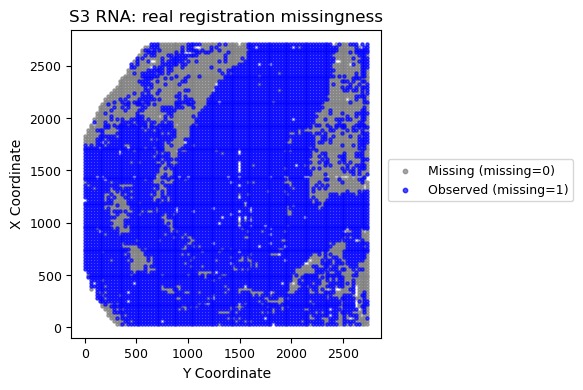

RNA-missing S2 locations: 2328/9230


In [4]:
# Display real RNA availability across S2 locations
missing_indices, observed_indices = show_real_missing(adata_target_raw, spatial_key="spatial", label_key="missing", plot=True,
                                                      figsize=(4, 4), s=5, title="S3 RNA: real registration missingness")

print(f"RNA-missing S2 locations: {len(missing_indices)}/{adata_target_raw.n_obs}")

In [5]:
# Preprocess source (H3K27ac) and target (RNA) model inputs
adata_source, _ = preprocess_omics(adata_source_raw, modality="ATAC", missing_key="missing", n_peak=50000,
                                   n_comps=50, data_role="source", use_lsi_as_X=True)

adata_target, _ = preprocess_omics(adata_target_raw, modality="RNA", missing_key="missing", min_cells=10,
                                   hvgs=3000, data_role="target")

print("H3K27ac shape after preprocessing:", adata_source.shape)
print("RNA shape after preprocessing:", adata_target.shape)

ATAC shape after preprocessing: (9230, 50)
RNA shape after preprocessing: (9230, 3000)


In [6]:
# Construct the H3K27ac-LSI similarity prior
distance_matrix, _ = compute_similarity_prior(adata_source, adata_target, PRIOR_PATH, device=DEVICE,
                                              covet_k_spatial=8, covet_gene_num=None, covet_use_layer=None,
                                              covet_use_obsm="X_lsi", spatial_key="spatial", missing_key="missing",
                                              store_neighbor_index=True, evaluate_prior=False)

Step 1: src COVET
Computing COVET using obsm 'X_lsi' with 50 dimensions
Calculating covariance matrices for all cells/spots
Computing matrix square root.
[COVET | auto missing-aware mode]
Original n_obs : 9230
Reference n_obs: 9230
has missing    : False
missing cells  : 0
observed cells : 9230
k_spatial used     : 8
batch_key used     : -1
COVET shape        : (9230, 50, 50)
COVET_SQRT shape   : (9230, 50, 50)
Number of CovGenes : 50

Step 2: src AOT
[AOT] representation=full COVET_SQRT flatten
[AOT] n=9230, d=2500, k_env=9229, backend=torch
[AOT] distances stored are squared Euclidean/Frobenius distances.
[AOT/torch] device=cuda:6
[AOT/torch] processed 9230/9230
[AOT] saved adata.obsp['aot_distances_ref'] shape=(9230, 9230), nnz=85183670
[AOT | auto missing-aware mode]
Reference AOT shape      : (9230, 9230)
Reference AOT nnz        : 85183670
Original-space AOT shape : (9230, 9230)
Original-space AOT nnz   : 85183670
k_env used               : 9229
AOT feature shape        : (9230, 

------Calculating spatial graph...
The graph contains 60070 edges, 9230 cells.
6.5081 neighbors per cell on average.


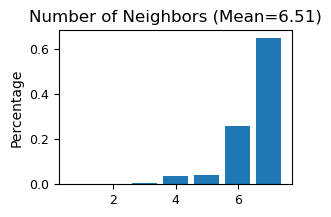

------Calculating spatial graph...
The graph contains 60070 edges, 9230 cells.
6.5081 neighbors per cell on average.


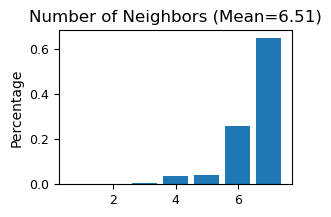

In [7]:
# Constructing spatial graphs
PRISM.Cal_Spatial_Net(adata_source, rad_cutoff=39)
PRISM.Stats_Spatial_Net(adata_source)
PRISM.Cal_Spatial_Net(adata_target, rad_cutoff=39)
PRISM.Stats_Spatial_Net(adata_target)

In [8]:
# Train PRISM on real RNA incompleteness
adata_source_out, adata_target_out = PRISM.train_PRISM(adata_source, adata_target, distance_matrix,
                                                       k_top=5, n_epochs=1000, lr=8e-4,
                                                       output_dir=str(RESULTS_DIR), file_prefix=RUN_PREFIX, 
                                                       device=DEVICE, patience=20, min_epochs=50, 
                                                       center_drop_rate=0.1, noise=0.1,
                                                       load_model_path=False, interaction_pca=True)

Similarity prior ready: 9230 cells, 5 observed neighbors per cell.



>>> Early stopping at epoch 360.
PRISM training and inference complete: P22_mouse_PRISM


### Task 1: Spatial-domain identification

Task 1 clusters `PRISM_emb_base` to delineate spatial domains at S2 coordinates. The [Allen Mouse Brain Atlas](https://atlas.brain-map.org/atlas?atlas=1) provides a public anatomical reference for interpreting the resulting structure, but is not used to supervise, align or quantify clustering in this tutorial.


fitting ...
  |======================================================================| 100%


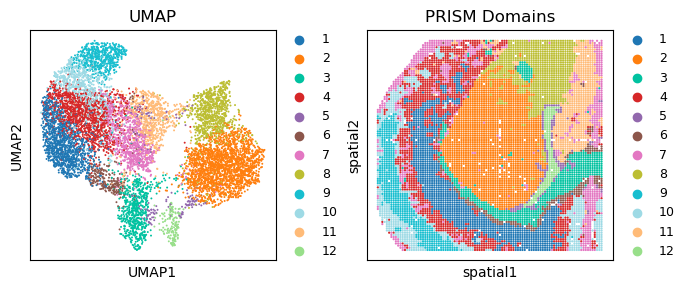

In [19]:
# Identify S2 spatial domains from the PRISM embedding
adata_clustered, domain_metrics = run_clustering_eval_plot(adata_source_out, emb_key="PRISM_emb",
                                                           label_key="reference_domain", cluster_key="PRISM_mclust",
                                                           n_clusters=12, s=10, use_pca=True, align_labels=False,
                                                           aligned_key="PRISM_domain", dataset_name="p22_mouse_brain")

### Task 2: Missing-omics imputation

Task 2 compares the raw gene reference pattern with the RNA field retained after scSLAT registration and the PRISM-completed field. This visualization assesses whether completion extends the observed spatial pattern into target-unregistered S2 locations.

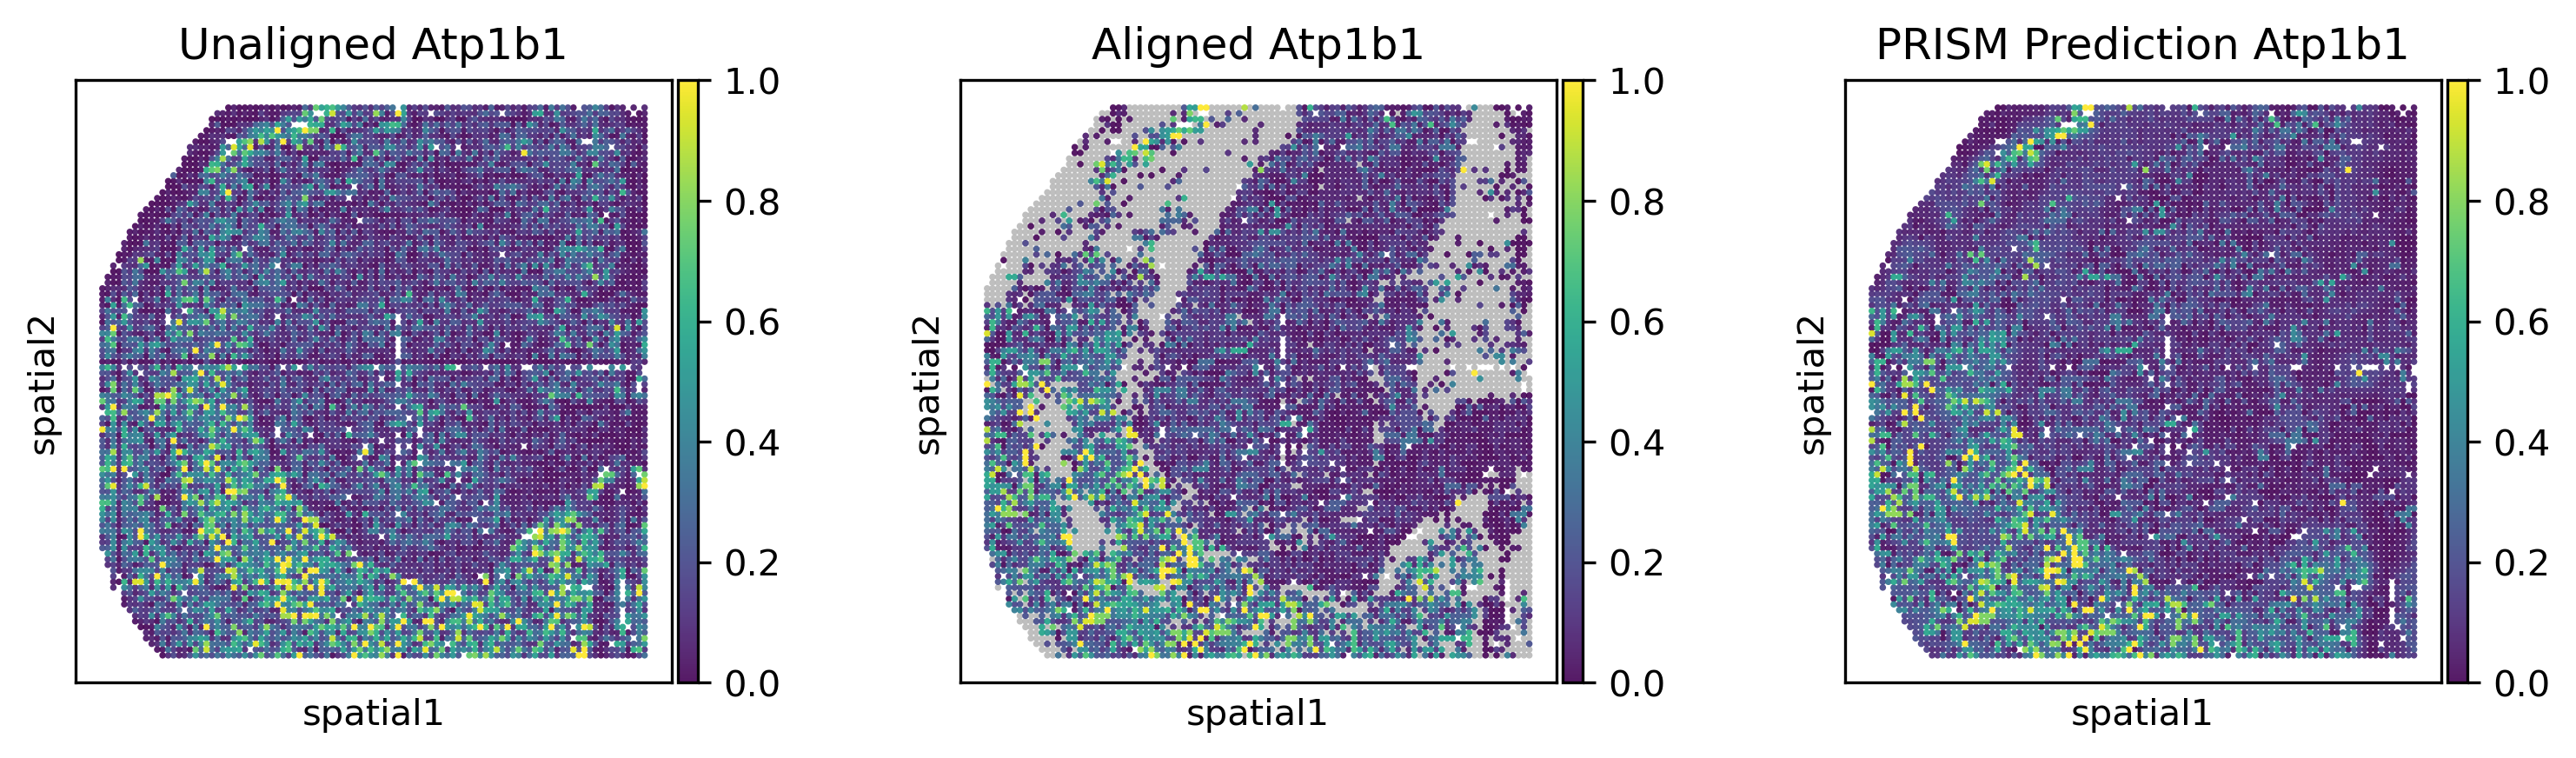

In [10]:
# Compare observed and completed representative gene spatial patterns
imputation_panel = plot_task2_real_three_panel(adata_aligned=adata_target_out, prior_matrix=distance_matrix,
                                               save_files=False, output_dir=RESULTS_DIR, file_prefix=RUN_PREFIX,
                                               adata_unaligned_raw=adata_reference_raw, feature="Atp1b1",
                                               show_missing_only=False)